<a href="https://colab.research.google.com/github/sravand2001/guild-mle-projects/blob/main/Student_MLE_MiniProject_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#import all the libraries we'll be using.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [4]:

# Load data and split into feature and target variables
data = load_breast_cancer()

In [5]:
# View first 5 rows of the data
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# How frequently does the positive target occur?
df["target"] = data.target
positive_rate = df["target"].mean()
print(f"Positive frequency: {positive_rate:.2%}")

Positive frequency: 62.74%


In [8]:
# Generate summary statistics for the data
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


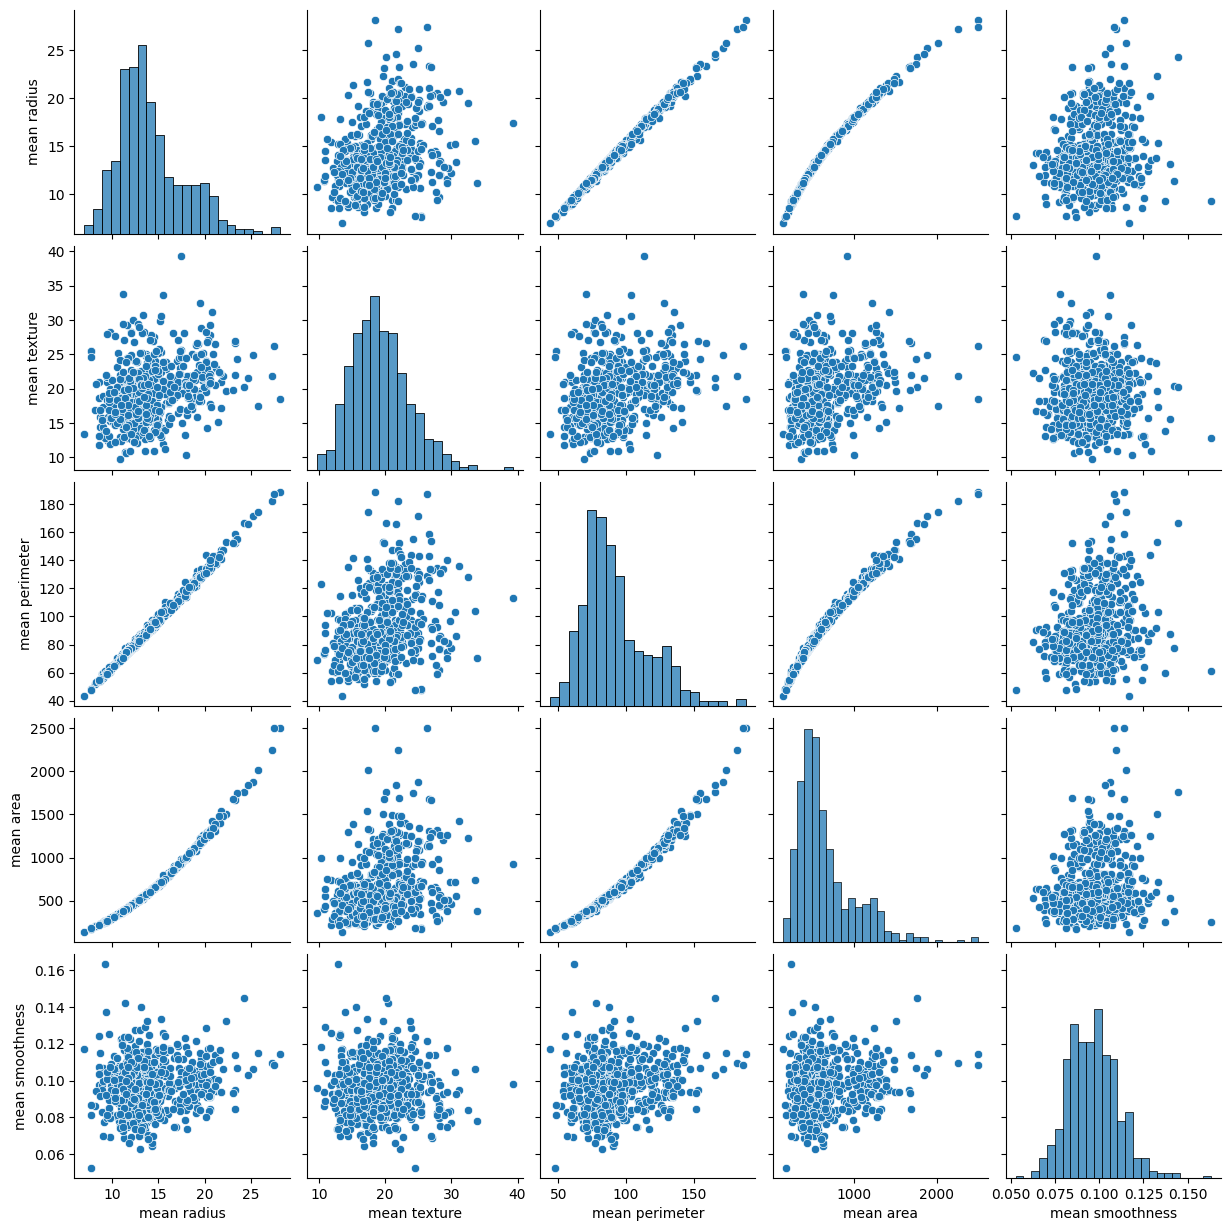

In [9]:
# Create a pairplot for the first few features
selected_features = df.columns[:5]

sns.pairplot(df[list(selected_features)])

<Axes: >

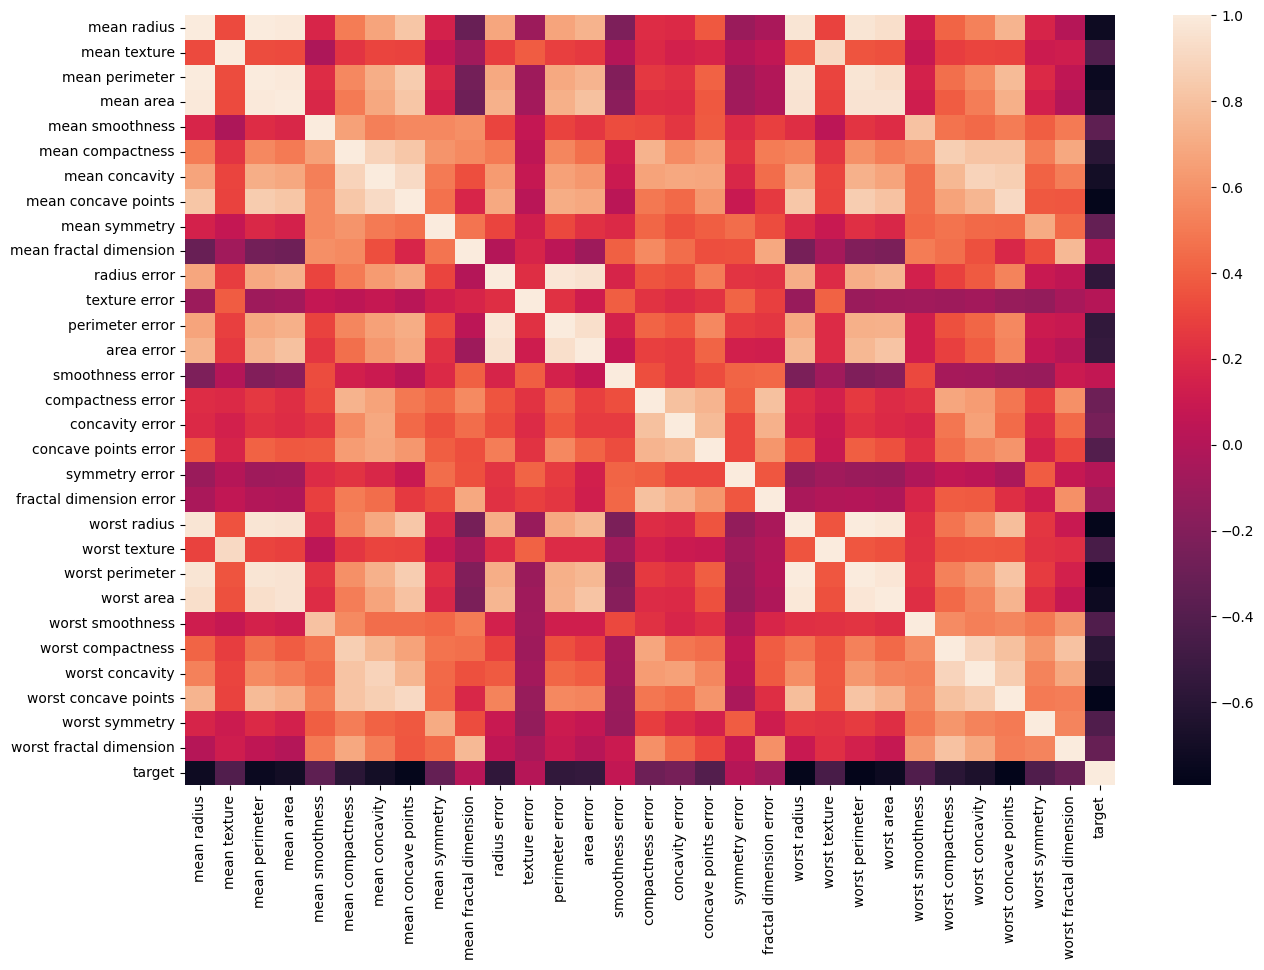

In [10]:
# Create a correlation coefficeint heatmap
plt.figure(figsize=(15, 10))
corr_matrix = df.corr()
sns.heatmap(
    corr_matrix
)

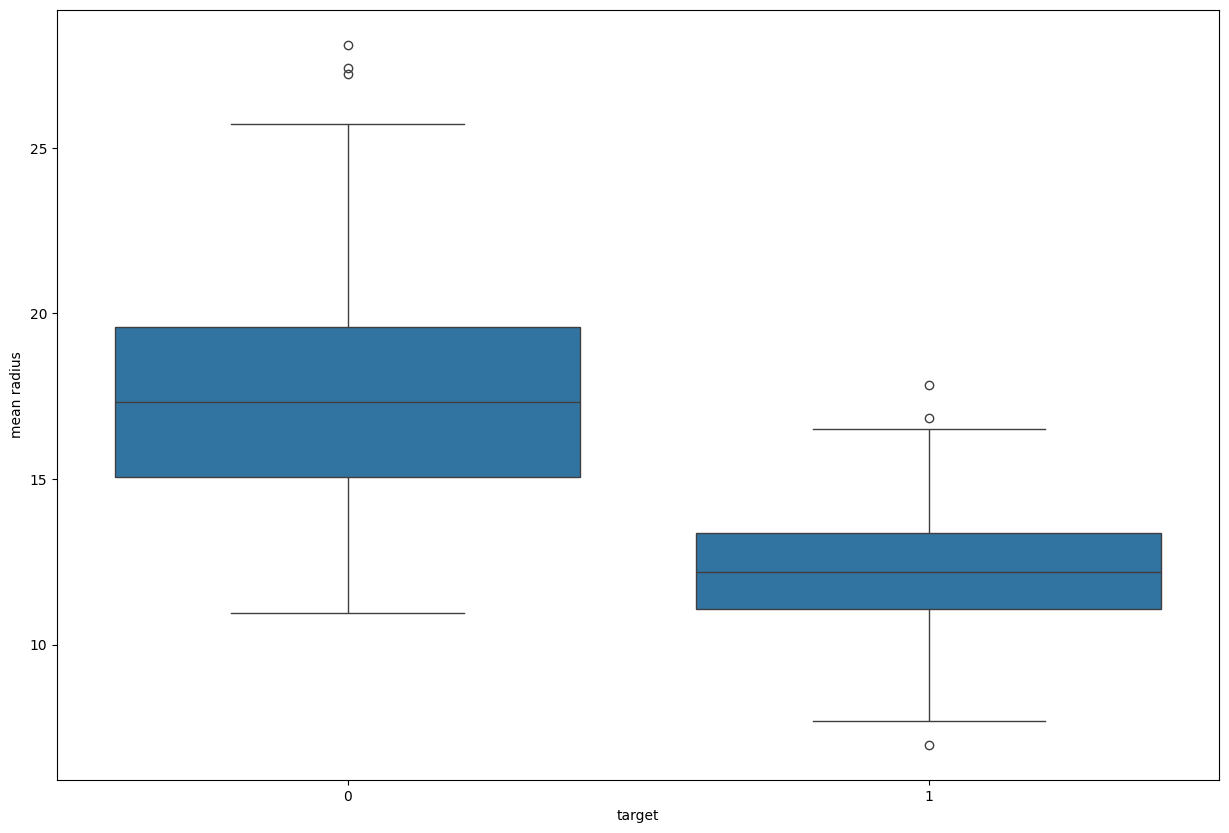

In [11]:
# Create a boxplot for mean radius by target type
plt.figure(figsize=(15, 10))

sns.boxplot(
    x="target",
    y="mean radius",
    data=df
)


plt.show()

In [13]:
# Split data into training and test sets
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Build and train logistic regression model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [15]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9824561403508771


In [16]:
# Generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")

Confusion Matrix:
 [[41  1]
 [ 1 71]]
False Positives: 1
False Negatives: 1


In [17]:
# Generate a classification report
report = classification_report(y_test, y_pred, target_names=["malignant", "benign"])
print(report)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [18]:
# Extract coefficients
coefficients = model.coef_[0]
intercept = model.intercept_[0]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=True)

print(coef_df)

                    Feature  Coefficient
25        worst compactness     0.055514
14         smoothness error    -0.160276
16          concavity error     0.160563
8             mean symmetry    -0.167233
29  worst fractal dimension    -0.187251
9    mean fractal dimension     0.199732
4           mean smoothness    -0.212479
11            texture error     0.248823
18           symmetry error     0.360492
19  fractal dimension error     0.437894
17     concave points error    -0.443784
2            mean perimeter    -0.476298
0               mean radius    -0.511479
3                 mean area    -0.541059
12          perimeter error    -0.544333
1              mean texture    -0.552698
6            mean concavity    -0.602103
15        compactness error     0.647227
5          mean compactness     0.648342
7       mean concave points    -0.704156
24         worst smoothness    -0.746625
22          worst perimeter    -0.763220
26          worst concavity    -0.823151
13              

In [19]:
# Normalize the coefficients by the standard deviation
feature_std = X_train.std()
feature_std.head()
coefficients = model.coef_[0]

normalized_coeffs = coefficients * feature_std

In [20]:
# Sort feature names and coefficients by absolute value of coefficients
norm_coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Normalized_Coefficient": normalized_coeffs
}).sort_values(by="Normalized_Coefficient", key=abs, ascending=False)

norm_coef_df

,Feature,Normalized_Coefficient
worst area,worst area,-524.039744
mean area,mean area,-186.635444
area error,area error,-38.802354
worst perimeter,worst perimeter,-25.335131
mean perimeter,mean perimeter,-11.502228
worst texture,worst texture,-7.813513
worst radius,worst radius,-4.520148
mean texture,mean texture,-2.434794
mean radius,mean radius,-1.789859
perimeter error,perimeter error,-1.074228


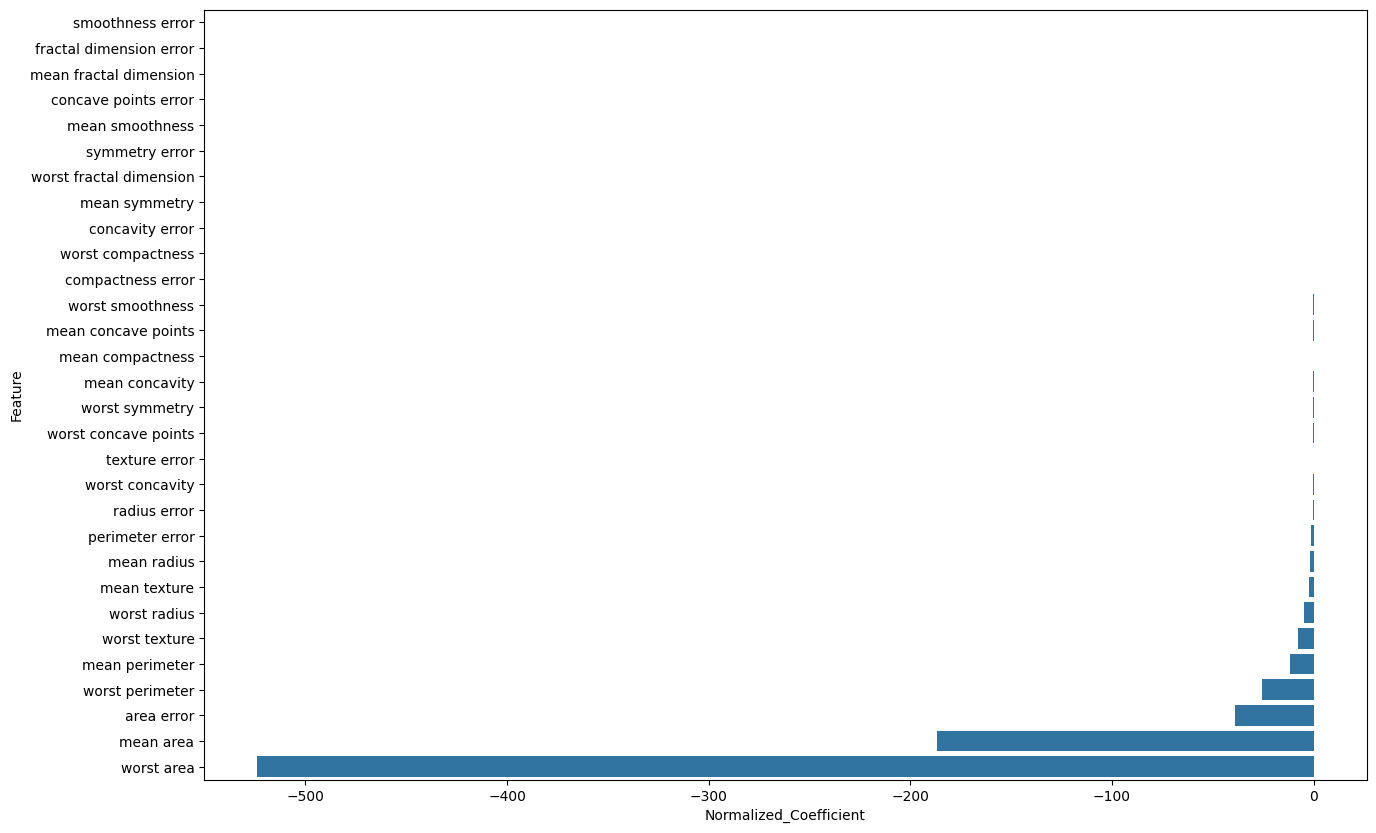

In [21]:
# Visualize feature importances
sorted_df = norm_coef_df.reindex(
    norm_coef_df["Normalized_Coefficient"].abs().sort_values(ascending=True).index
)

plt.figure(figsize=(15, 10))

sns.barplot(
    x="Normalized_Coefficient",
    y="Feature",
    data=sorted_df,
    legend=False
)


plt.show()